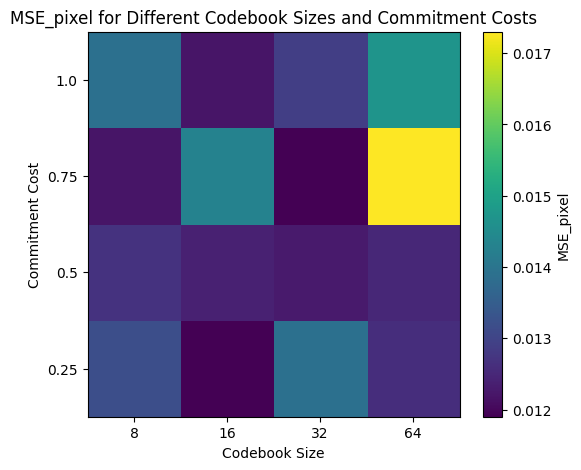

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the axes
codebook_sizes = [8, 16, 32, 64]
commitment_costs = [0.25, 0.5, 0.75, 1.0]

# MSE values provided in the order:
# For each codebook size (8, 16, 32, 64), the commitment costs were tested in the sequence [0.5, 0.25, 0.75, 1.0].
# We map them into a 4x4 matrix where rows correspond to [0.25, 0.5, 0.75, 1.0]
# and columns correspond to [8, 16, 32, 64].

mse_values = [
    # Codebook = 8:  [cost 0.5,  cost 0.25, cost 0.75, cost 1.0]
    [0.0127, 0.0132, 0.0122, 0.0139],
    # Codebook = 16: [cost 0.5,  cost 0.25, cost 0.75, cost 1.0]
    [0.0124, 0.0119, 0.0143, 0.0122],
    # Codebook = 32: [cost 0.5,  cost 0.25, cost 0.75, cost 1.0]
    [0.0123, 0.0139, 0.0119, 0.0129],
    # Codebook = 64: [cost 0.5,  cost 0.25, cost 0.75, cost 1.0]
    [0.0125, 0.0126, 0.0173, 0.0147]
]

# Initialize a 4x4 matrix
data_matrix = np.zeros((4, 4))

# Fill the matrix: each column is one codebook size, each row is one cost in ascending order
for col_idx, col_vals in enumerate(mse_values):
    # col_vals are in order [cost 0.5, cost 0.25, cost 0.75, cost 1.0]
    ordering = {0.25: 0, 0.5: 1, 0.75: 2, 1.0: 3}
    # We have to map each value to the correct row
    for idx, cost in enumerate([0.5, 0.25, 0.75, 1.0]):
        row_idx = ordering[cost]
        data_matrix[row_idx, col_idx] = col_vals[idx]

# Plotting
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(data_matrix, aspect='auto', origin='lower')

# Labels and ticks
ax.set_xticks(np.arange(len(codebook_sizes)))
ax.set_xticklabels([str(cb) for cb in codebook_sizes])
ax.set_xlabel("Codebook Size")

ax.set_yticks(np.arange(len(commitment_costs)))
ax.set_yticklabels([str(cc) for cc in commitment_costs])
ax.set_ylabel("Commitment Cost")

ax.set_title("MSE_pixel for Different Codebook Sizes and Commitment Costs")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("MSE_pixel")

plt.show()
